环境准备

In [2]:
import math
import time
import numpy as np

import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


## 2 多层感知机

### 2.1 理论计算题

#### 1. 非线性激活函数的重要性

假设一个具有单隐藏层的多层感知机，输入为 $\mathbf{x}$，隐藏层没有激活函数（线性激活）：
$$
\mathbf{h} = \mathbf{W}_1 \mathbf{x} + \mathbf{b}_1,
\quad
\mathbf{o} = \mathbf{W}_2 \mathbf{h} + \mathbf{b}_2.
$$

将 $\mathbf{h}$ 代入 $\mathbf{o}$：
$$
\mathbf{o} = \mathbf{W}_2 (\mathbf{W}_1 \mathbf{x} + \mathbf{b}_1) + \mathbf{b}_2
= (\mathbf{W}_2 \mathbf{W}_1) \mathbf{x} + (\mathbf{W}_2 \mathbf{b}_1 + \mathbf{b}_2).
$$

令 $\mathbf{W}' = \mathbf{W}_2 \mathbf{W}_1$，$\mathbf{b}' = \mathbf{W}_2 \mathbf{b}_1 + \mathbf{b}_2$，则网络等价于单层神经网络：
$$
\mathbf{o} = \mathbf{W}' \mathbf{x} + \mathbf{b}'.
$$

**结论**：没有非线性激活函数的“多层”网络实质上退化成了线性变换，无法逼近任何非线性函数，因此非线性激活函数对于多层感知机的表达能力至关重要。

#### 2. 激活函数性质分析

**Sigmoid**  
  $$
  \sigma(x) = \frac{1}{1+e^{-x}}, \quad
  \sigma'(x) = \sigma(x) \cdot (1-\sigma(x)).
  $$

**tanh**  
  $$
  \tanh(x) = \frac{e^{x}-e^{-x}}{e^{x}+e^{-x}}, \quad
  \tanh'(x) = 1 - \tanh^2(x).
  $$

## 2.2 编程题：从零实现 Fashion-MNIST 单隐藏层 MLP


In [3]:
# 数据加载：Fashion-MNIST

batch_size = 256

transform = transforms.Compose([
    transforms.ToTensor(),
])

train_ds = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_ds  = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# 划分验证集
val_ratio = 0.1
n_train = int((1 - val_ratio) * len(train_ds))
n_val = len(train_ds) - n_train
train_ds, val_ds = torch.utils.data.random_split(train_ds, [n_train, n_val], generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

len(train_loader), len(val_loader), len(test_loader)

(211, 24, 40)

In [4]:

def init_params(d_in, d_hidden, d_out, weight_std=0.01, device=device):
    """正态分布初始化参数。"""
    W1 = torch.randn(d_in, d_hidden, device=device) * weight_std
    b1 = torch.zeros(d_hidden, device=device)
    W2 = torch.randn(d_hidden, d_out, device=device) * weight_std
    b2 = torch.zeros(d_out, device=device)
    # 明确要求：手动管理梯度，因此不使用 autograd
    return W1, b1, W2, b2


def relu(x):
    return torch.clamp(x, min=0.0)


def relu_backward(dout, x):
    """ReLU 的反向：x 为 pre-activation"""
    dx = dout.clone()
    dx[x <= 0] = 0
    return dx


def softmax(logits):
    """数值稳定 softmax"""
    z = logits - logits.max(dim=1, keepdim=True).values
    exp_z = torch.exp(z)
    return exp_z / exp_z.sum(dim=1, keepdim=True)


def cross_entropy_with_logits(logits, y):
    """返回 (loss_mean, probs)。y 为 int64 类别索引。
    这里显式写出 softmax + NLL，保持可读性。
    """
    probs = softmax(logits)
    # 取正确类别概率
    p = probs.gather(1, y.view(-1, 1)).squeeze(1)
    # 避免 log(0)
    loss = -torch.log(p + 1e-12)
    return loss.mean(), probs


def accuracy_from_logits(logits, y):
    pred = logits.argmax(dim=1)
    return (pred == y).float().mean().item()


def forward_mlp(X, params, dropout=0.0, is_training=True):
    """单隐藏层 MLP 前向。
    返回 logits 和 cache，用于手动反向。
    """
    W1, b1, W2, b2 = params
    # Flatten
    X2 = X.view(X.shape[0], -1)

    z1 = X2 @ W1 + b1  # [B, H]
    h1 = relu(z1)

    mask = None
    if dropout > 0:
        if is_training:
            # inverted dropout
            keep_prob = 1.0 - dropout
            mask = (torch.rand_like(h1) < keep_prob).float() / keep_prob
            h1 = h1 * mask
        else:
            mask = None

    logits = h1 @ W2 + b2  # [B, C]
    cache = {
        'X2': X2,
        'z1': z1,
        'h1': h1,
        'mask': mask,
        'dropout': dropout,
        'is_training': is_training
    }
    return logits, cache


def backward_mlp(dlogits, params, cache, weight_decay=0.0):
    """手动反向传播，返回 grads: dW1, db1, dW2, db2。
    dlogits: [B,C]，对应 loss 对 logits 的梯度。
    weight_decay: L2 系数（对 W1, W2 添加梯度项）。
    """
    W1, b1, W2, b2 = params
    X2 = cache['X2']
    z1 = cache['z1']
    h1 = cache['h1']
    mask = cache['mask']

    # logits = h1 @ W2 + b2
    dW2 = h1.t() @ dlogits
    db2 = dlogits.sum(dim=0)
    dh1 = dlogits @ W2.t()

    # dropout backward
    if mask is not None:
        dh1 = dh1 * mask

    # h1 = relu(z1)
    dz1 = relu_backward(dh1, z1)

    # z1 = X2 @ W1 + b1
    dW1 = X2.t() @ dz1
    db1 = dz1.sum(dim=0)

    # 平均到 batch（让学习率与 batch size 更无关）
    B = X2.shape[0]
    dW1 /= B
    db1 /= B
    dW2 /= B
    db2 /= B

    # L2 正则：对 loss 加 (lambda/2)*||W||^2 => 对梯度加 lambda*W
    if weight_decay > 0:
        dW1 = dW1 + weight_decay * W1
        dW2 = dW2 + weight_decay * W2

    return dW1, db1, dW2, db2


def sgd_step(params, grads, lr, weight_decay_step=0.0):
    """SGD 更新。
    若启用权重衰减（题目 3.2.1 的形式）：旧权重先乘 (1 - lr*lambda)，再减 lr*grad。
    这里 weight_decay_step 对 W1/W2 生效。
    """
    W1, b1, W2, b2 = params
    dW1, db1, dW2, db2 = grads

    if weight_decay_step > 0:
        W1 = W1 * (1 - lr * weight_decay_step)
        W2 = W2 * (1 - lr * weight_decay_step)

    W1 = W1 - lr * dW1
    b1 = b1 - lr * db1
    W2 = W2 - lr * dW2
    b2 = b2 - lr * db2

    return (W1, b1, W2, b2)


def softmax_ce_backward(probs, y):
    """Softmax+CE 对 logits 的梯度： (p - onehot)/B
    这里返回未除 B 的版本，后面 backward 会除 B。
    """
    B, C = probs.shape
    onehot = torch.zeros_like(probs)
    onehot.scatter_(1, y.view(-1, 1), 1.0)
    return (probs - onehot)  # [B,C]


@torch.no_grad()
def evaluate(loader, params, dropout=0.0):
    total_loss = 0.0
    total_acc = 0.0
    total_n = 0
    for X, y in loader:
        X = X.to(device)
        y = y.to(device)
        logits, _ = forward_mlp(X, params, dropout=dropout, is_training=False)
        loss, _ = cross_entropy_with_logits(logits, y)
        acc = accuracy_from_logits(logits, y)
        n = X.shape[0]
        total_loss += loss.item() * n
        total_acc += acc * n
        total_n += n
    return total_loss / total_n, total_acc / total_n

c:\conda\envs\alfy\lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


[Epoch 1/5] train loss=0.7989 acc=0.7014 | val loss=0.6858 acc=0.7423 | time=29.9s
[Epoch 2/5] train loss=0.4919 acc=0.8177 | val loss=0.4424 acc=0.8403 | time=29.1s
[Epoch 3/5] train loss=0.4291 acc=0.8413 | val loss=0.4284 acc=0.8473 | time=28.9s
[Epoch 4/5] train loss=0.4005 acc=0.8520 | val loss=0.4300 acc=0.8402 | time=29.0s
[Epoch 5/5] train loss=0.3781 acc=0.8599 | val loss=0.3751 acc=0.8687 | time=28.6s
Test  loss=0.3965 acc=0.8601


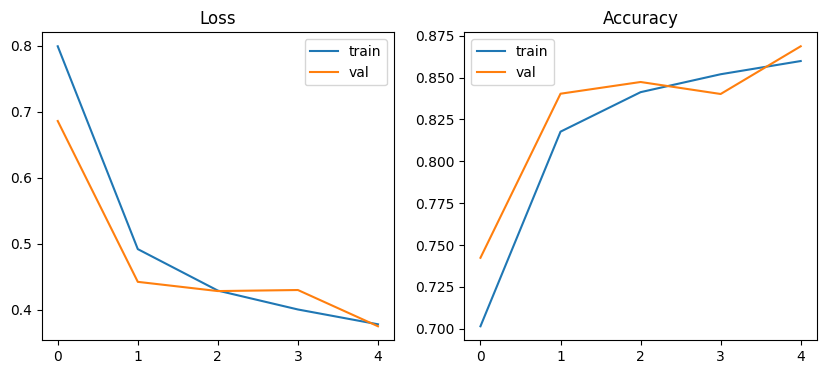

In [5]:
# 训练一个基础 MLP

d_in = 28 * 28
d_hidden = 256
d_out = 10

params = init_params(d_in, d_hidden, d_out, weight_std=0.01, device=device)

lr = 0.5
epochs = 5

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for ep in range(1, epochs + 1):
    t0 = time.time()
    # train
    running_loss = 0.0
    running_acc = 0.0
    n_seen = 0
    for X, y in train_loader:
        X = X.to(device)
        y = y.to(device)

        logits, cache = forward_mlp(X, params, dropout=0.0, is_training=True)
        loss, probs = cross_entropy_with_logits(logits, y)
        dlogits = softmax_ce_backward(probs, y)
        grads = backward_mlp(dlogits, params, cache, weight_decay=0.0)
        params = sgd_step(params, grads, lr=lr, weight_decay_step=0.0)

        acc = accuracy_from_logits(logits, y)
        n = X.shape[0]
        running_loss += loss.item() * n
        running_acc += acc * n
        n_seen += n

    tr_loss = running_loss / n_seen
    tr_acc = running_acc / n_seen

    va_loss, va_acc = evaluate(val_loader, params, dropout=0.0)

    train_losses.append(tr_loss)
    val_losses.append(va_loss)
    train_accs.append(tr_acc)
    val_accs.append(va_acc)

    print(f"[Epoch {ep}/{epochs}] train loss={tr_loss:.4f} acc={tr_acc:.4f} | val loss={va_loss:.4f} acc={va_acc:.4f} | time={time.time()-t0:.1f}s")

# 测试集
te_loss, te_acc = evaluate(test_loader, params, dropout=0.0)
print(f"Test  loss={te_loss:.4f} acc={te_acc:.4f}")

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='val')
plt.title('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accs, label='train')
plt.plot(val_accs, label='val')
plt.title('Accuracy')
plt.legend()
plt.show()

# 3 模型选择，权重衰减和丢弃法

## 3.1 理论计算题

### 3.1.1 过拟合与欠拟合

训练误差（Training Error）：模型在训练集上的平均损失/错误率。
泛化误差（Generalization Error）：模型在未见过的数据（测试集/真实分布）上的平均损失/错误率。

当 训练误差极低但泛化误差很高 时，模型处于：过拟合（Overfitting） 状态。

缓解方法（控制模型复杂度）：
1. 降低模型容量：减少隐藏单元、减少层数、限制多项式次数等。
2. 加入正则化：如 L2（权重衰减）、L1。
3. 使用 Dropout：训练时随机失活部分神经元，抑制共适应。
4. 早停（Early Stopping）：监控验证误差，开始上升时停止训练。
5. 增加数据或数据增强：从数据侧降低有效复杂度。


### 3.1.2 K 折交叉验证

K 折交叉验证（K-fold CV）算法步骤：

1. 将数据集随机打乱并划分为 K 个互不重叠的子集（折）\(D_1,\dots,D_K\)。
2. 对于每个 \(k=1,\dots,K\)：
使用 \(D_k\) 作为验证集。
使用其余 \(K-1\) 个折的并集作为训练集。
训练模型并在 \(D_k\) 上评估验证指标（如 loss/acc）。
3. 得到 K 次验证结果，取 **平均值**（及方差）作为该超参数/模型的性能估计。
4. 在选择最优超参数后，通常用全量训练集重新训练，再在独立测试集上评估。


## 3.2 编程题：加入 L2 正则与 Dropout，并做对比实验

=== 无正则化 ===
Epoch 100: train loss=0.1363, val loss=0.1685
Epoch 200: train loss=0.1039, val loss=0.1255
Epoch 300: train loss=0.0934, val loss=0.1139
Epoch 400: train loss=0.0863, val loss=0.1093
Epoch 500: train loss=0.0805, val loss=0.1071

=== 权重衰减 ===
Epoch 100: train loss=0.1504, val loss=0.1782
Epoch 200: train loss=0.1173, val loss=0.1404
Epoch 300: train loss=0.1053, val loss=0.1296
Epoch 400: train loss=0.0982, val loss=0.1254
Epoch 500: train loss=0.0928, val loss=0.1232

=== Dropout ===
Epoch 100: train loss=0.1728, val loss=0.1467
Epoch 200: train loss=0.1456, val loss=0.1244
Epoch 300: train loss=0.1255, val loss=0.1163
Epoch 400: train loss=0.1306, val loss=0.1130
Epoch 500: train loss=0.1157, val loss=0.1125


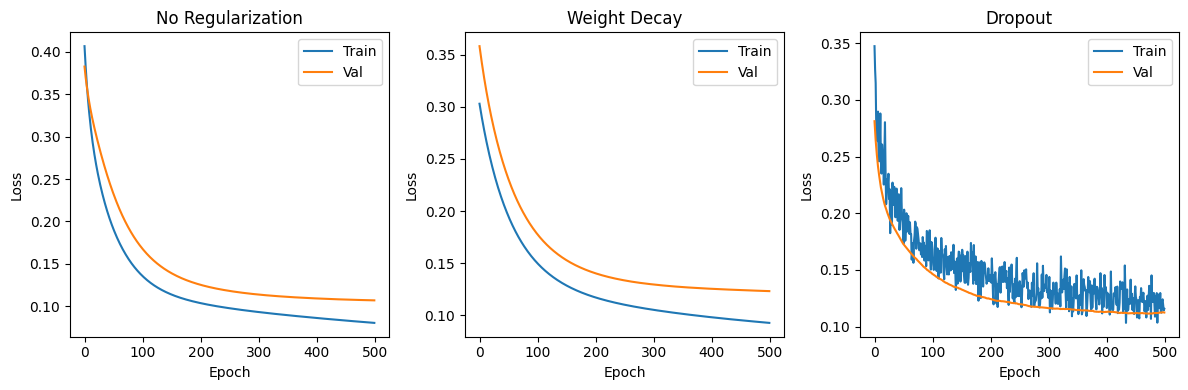

In [2]:
import torch
import matplotlib.pyplot as plt

# 生成高维数据
torch.manual_seed(42)
X = torch.rand(200, 10) * 2 - 1
y = 0.5 * (X[:,0]**2 + torch.sin(3*X[:,1]) + X[:,2]*X[:,3] + X[:,4]**3) + torch.randn(200)*0.2
split = 160
X_train, y_train = X[:split], y[:split]
X_val, y_val = X[split:], y[split:]

hidden_dim = 256
lr = 0.01
weight_decay = 0.01
dropout_rate = 0.5

def init_params():
    W1 = torch.randn(10, hidden_dim) * 0.1
    b1 = torch.zeros(hidden_dim)
    W2 = torch.randn(hidden_dim, 1) * 0.1
    b2 = torch.zeros(1)
    return W1, b1, W2, b2

def dropout_layer(X, dropout, is_train):
    if not is_train or dropout == 0:
        return X
    mask = (torch.rand_like(X) > dropout).float()
    return mask * X / (1.0 - dropout)

def forward(X, W1, b1, W2, b2, is_train, dropout):
    Z1 = X @ W1 + b1
    H = torch.relu(Z1)
    H = dropout_layer(H, dropout, is_train)
    out = H @ W2 + b2
    return Z1, H, out

def mse_loss(pred, y):
    return ((pred.squeeze() - y) ** 2).mean()

def train_model(use_wd, use_drop, epochs=500):
    W1, b1, W2, b2 = init_params()
    train_losses, val_losses = [], []
    for epoch in range(epochs):
        Z1, H, pred = forward(X_train, W1, b1, W2, b2, True, dropout_rate if use_drop else 0)
        loss = mse_loss(pred, y_train)
        # grad
        N = X_train.shape[0]
        dout = 2 * (pred.squeeze() - y_train).unsqueeze(1) / N
        dW2 = H.T @ dout
        db2 = dout.sum(0)
        dH = dout @ W2.T
        dZ1 = dH * (Z1 > 0).float()
        dW1 = X_train.T @ dZ1
        db1 = dZ1.sum(0)
        with torch.no_grad():
            if use_wd:
                W1 = (1 - lr * weight_decay) * W1 - lr * dW1
                W2 = (1 - lr * weight_decay) * W2 - lr * dW2
            else:
                W1 -= lr * dW1
                W2 -= lr * dW2
            b1 -= lr * db1
            b2 -= lr * db2
        # validation
        with torch.no_grad():
            _, _, pred_val = forward(X_val, W1, b1, W2, b2, False, 0)
            val_loss = mse_loss(pred_val, y_val)
        train_losses.append(loss.item())
        val_losses.append(val_loss.item())
        if (epoch+1) % 100 == 0:
            print(f"Epoch {epoch+1}: train loss={loss.item():.4f}, val loss={val_loss.item():.4f}")
    return train_losses, val_losses

print("=== 无正则化 ===")
loss1 = train_model(False, False)
print("\n=== 权重衰减 ===")
loss2 = train_model(True, False)
print("\n=== Dropout ===")
loss3 = train_model(False, True)

plt.figure(figsize=(12,4))
titles = ['No Regularization', 'Weight Decay', 'Dropout']
for i, (train_losses, val_losses) in enumerate([loss1, loss2, loss3]):
    plt.subplot(1,3,i+1)
    plt.plot(train_losses, label='Train')
    plt.plot(val_losses, label='Val')
    plt.title(titles[i])
    plt.legend()
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
plt.tight_layout()
plt.show()

## 4 数值稳定性和激活函数

### 4.1 理论计算题

#### 1. 梯度消失与梯度爆炸

对于 $d$ 层网络，梯度反向传播时包含 $\prod_{i=t}^{d-1} \frac{\partial h^{i+1}}{\partial h^i}$ 项，每个因子是雅可比矩阵。

- **梯度爆炸**：如果每层矩阵的谱半径 $>1$，且激活函数导数 $\sigma'(z)$ 在饱和区外接近1，则连乘积范数指数增长。典型场景：权重初始化过大。
- **梯度消失**：如果每层矩阵的谱半径 $<1$，或使用饱和激活函数（如Sigmoid），其导数最大值仅为0.25，多层连乘后梯度趋近0。

#### 2. ReLU缓解梯度消失的原因

ReLU 的导数：$\text{ReLU}'(x) = \begin{cases}1 & x>0 \\ 0 & x\le0\end{cases}$。当 $x>0$ 时，梯度为1，不会缩小梯度；当 $x\le 0$ 时，神经元关闭，梯度为0，但不会发生指数衰减。这种非饱和特性使得深层网络中正半轴的梯度能完整传播，从而缓解梯度消失。

## 4.2 编程题：20 层网络的梯度消失/爆炸模拟与修复



[Sigmoid + Normal(std=1)] Expect vanishing gradients
loss=13.230641
First 3 layer grad norms: [185.1716766357422, 123.24524688720703, 87.90640258789062]
Last  3 layer grad norms: [6.571605205535889, 6.1389265060424805, 6.366094589233398]
Any NaN in grad norms? False

[ReLU + Normal(std=10)] May explode / overflow
loss=nan
First 3 layer grad norms: [nan, nan, nan]
Last  3 layer grad norms: [nan, nan, nan]
Any NaN in grad norms? True

[LeakyReLU + Xavier] More stable gradients
loss=2.302460
First 3 layer grad norms: [0.0019418231677263975, 0.001992982579395175, 0.002058033598586917]
Last  3 layer grad norms: [0.0015887568006291986, 0.0015699438517913222, 0.0011121684219688177]
Any NaN in grad norms? False


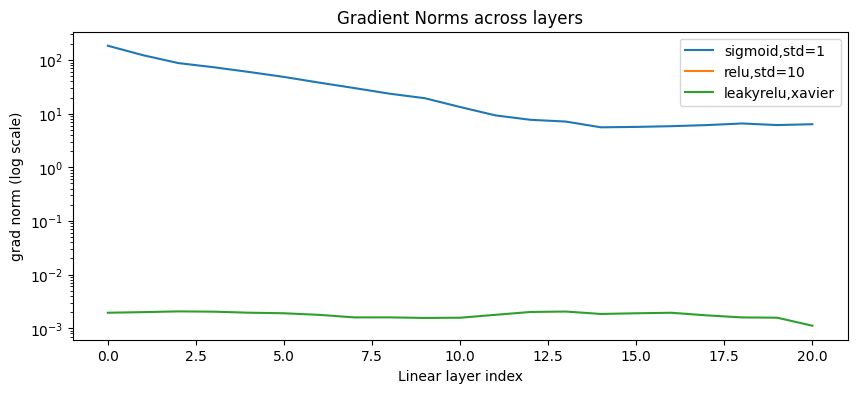

In [3]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import math

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def build_deep_net(activation='sigmoid', width=256, depth=20, in_dim=256, out_dim=10):
    layers = []
    dim = in_dim
    for i in range(depth):
        layers.append(nn.Linear(dim, width))
        if activation == 'sigmoid':
            layers.append(nn.Sigmoid())
        elif activation == 'relu':
            layers.append(nn.ReLU())
        elif activation == 'leakyrelu':
            layers.append(nn.LeakyReLU(0.1))
        else:
            raise ValueError('unknown activation')
        dim = width
    layers.append(nn.Linear(dim, out_dim))
    return nn.Sequential(*layers)


def init_all_linear(net, mode='normal', std=1.0):
    for m in net.modules():
        if isinstance(m, nn.Linear):
            if mode == 'normal':
                nn.init.normal_(m.weight, mean=0.0, std=std)
                nn.init.zeros_(m.bias)
            elif mode == 'xavier':
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)
            else:
                raise ValueError('unknown init mode')


def grad_norms(net):
    norms = []
    for m in net.modules():
        if isinstance(m, nn.Linear):
            if m.weight.grad is None:
                norms.append(float('nan'))
            else:
                norms.append(m.weight.grad.norm().item())
    return norms


def run_grad_experiment(activation, init_mode, std=1.0, title=''):
    net = build_deep_net(activation=activation, width=256, depth=20, in_dim=256, out_dim=10).to(device)
    init_all_linear(net, mode=init_mode, std=std)

    X = torch.randn(128, 256, device=device)
    y = torch.randint(0, 10, (128,), device=device)

    net.zero_grad(set_to_none=True)
    logits = net(X)
    loss = nn.CrossEntropyLoss()(logits, y)
    loss.backward()

    norms = grad_norms(net)
    print(f"\n{title}")
    print(f"loss={loss.item():.6f}")
    print("First 3 layer grad norms:", norms[:3])
    print("Last  3 layer grad norms:", norms[-3:])
    print("Any NaN in grad norms?", any([math.isnan(v) for v in norms]))
    return norms


# 4.2.2 Sigmoid + std=1 => 常见梯度消失
norms_sigmoid = run_grad_experiment(
    activation='sigmoid',
    init_mode='normal',
    std=1.0,
    title='[Sigmoid + Normal(std=1)] Expect vanishing gradients'
)

# 4.2.3 ReLU + std=10 => 可能爆炸/NaN
norms_relu_big = run_grad_experiment(
    activation='relu',
    init_mode='normal',
    std=10.0,
    title='[ReLU + Normal(std=10)] May explode / overflow'
)

# 4.2.4 Xavier + (Leaky)ReLU => 更稳定
norms_xavier = run_grad_experiment(
    activation='leakyrelu',
    init_mode='xavier',
    std=1.0,
    title='[LeakyReLU + Xavier] More stable gradients'
)

plt.figure(figsize=(10,4))
plt.plot(norms_sigmoid, label='sigmoid,std=1')
plt.plot(norms_relu_big, label='relu,std=10')
plt.plot(norms_xavier, label='leakyrelu,xavier')
plt.yscale('log')
plt.xlabel('Linear layer index')
plt.ylabel('grad norm (log scale)')
plt.title('Gradient Norms across layers')
plt.legend()
plt.show()

In [4]:
from IPython.display import display, Math, Latex

## 5.1 理论计算题：协变量偏移 vs 标签偏移

### 5.1.1 协变量偏移

**定义**：输入特征 \(x\) 的边缘分布在训练环境与测试环境中不同，但给定特征后的标签条件分布相同。用数学语言表示为：

$$
p_{\text{train}}(x) \neq p_{\text{test}}(x), \qquad p_{\text{train}}(y \mid x) = p_{\text{test}}(y \mid x).
$$

其中 \(p_{\text{train}}\) 表示训练分布，\(p_{\text{test}}\) 表示测试分布。

**实际例子:电商推荐**  
- **训练数据**：来自工作日的用户浏览行为。特征 \(x\) 包括：点击品类、浏览时长、设备类型等。这些数据中，办公用品相关特征突出，浏览时间集中在工作时段。  
- **测试数据**：周末或节假日的用户行为。特征分布发生变化：休闲娱乐类商品增多，浏览时段偏晚。  
- **条件分布不变**：对于同样的一组特征（例如点击某商品并停留较长时间），用户最终购买该商品的条件概率在训练和测试环境中相同。  
- **修正方法**：使用重要性权重 \(w(x) = \frac{p_{\text{test}}(x)}{p_{\text{train}}(x)}\) 对训练样本加权，使加权后的训练分布接近测试分布，从而降低泛化误差。

### 5.1.2 标签偏移（Label Shift）

**定义**：标签 \(y\) 的边缘分布在训练环境与测试环境中不同，但给定标签后的特征条件分布相同。即：

$$
p_{\text{train}}(y) \neq p_{\text{test}}(y), \qquad p_{\text{train}}(x \mid y) = p_{\text{test}}(x \mid y).
$$

**实际例子（医疗诊断）**  
- **训练数据**：来自普通体检人群，疾病患病率低（例如某癌症发病率 1%）。  
- **测试数据**：来自专科门诊或高危人群，疾病患病率升高（例如 20%）。  
- **条件分布不变**：对于同一疾病状态 \(y\)（患病/健康），患者的症状、检验指标等特征分布基本一致。  
- **修正方法**：估计测试集标签分布 \(p_{\text{test}}(y)\)，使用权重 \(w(y) = \frac{p_{\text{test}}(y)}{p_{\text{train}}(y)}\) 对训练样本重新加权。

### 5.1.3 区别与联系

| 对比项         | 协变量偏移                          | 标签偏移                          |
|--------------|-----------------------------------|---------------------------------|
| 变化的主体     | 输入 \(x\) 的边缘分布               | 输出 \(y\) 的边缘分布             |
| 不变的条件     | \(p(y \mid x)\) 不变               | \(p(x \mid y)\) 不变             |
| 修正方式       | 密度比 \(q(x)/p(x)\) 加权          | 密度比 \(q(y)/p(y)\) 加权         |

**联系**  
1.两者都是“训练‑测试分布不一致”的具体形式，均会导致模型在测试集上性能下降。  
2.均可通过重要性加权（密度比估计）进行校正。  
3.在实际问题中可能同时发生。

## 5.1 理论计算题：协变量偏移 vs 标签偏移

### 5.1.1 协变量偏移（Covariate Shift）

**定义**：输入特征 $x$ 的边缘分布在训练环境与测试环境中不同，但给定特征后的标签条件分布相同。用数学语言表示为：

$$
p_{\text{train}}(x) \neq p_{\text{test}}(x), \qquad p_{\text{train}}(y \mid x) = p_{\text{test}}(y \mid x).
$$

其中 $p_{\text{train}}$ 表示训练分布，$p_{\text{test}}$ 表示测试分布。

**实际例子（电商推荐）**  
1.**训练数据**：来自工作日的用户浏览行为。特征 $x$ 包括：点击品类、浏览时长、设备类型等。这些数据中，办公用品相关特征突出，浏览时间集中在工作时段。  
2.**测试数据**：周末或节假日的用户行为。特征分布发生变化：休闲娱乐类商品增多，浏览时段偏晚。  
3.**条件分布不变**：对于同样的一组特征（例如点击某商品并停留较长时间），用户最终购买该商品的条件概率在训练和测试环境中相同。 
4.**修正方法**：使用重要性权重 $w(x) = \frac{p_{\text{test}}(x)}{p_{\text{train}}(x)}$ 对训练样本加权，使加权后的训练分布接近测试分布，从而降低泛化误差。

### 5.1.2 标签偏移（Label Shift）

**定义**：标签 $y$ 的边缘分布在训练环境与测试环境中不同，但给定标签后的特征条件分布相同。即：

$$
p_{\text{train}}(y) \neq p_{\text{test}}(y), \qquad p_{\text{train}}(x \mid y) = p_{\text{test}}(x \mid y).
$$

**实际例子（医疗诊断）**  
- **训练数据**：来自普通体检人群，疾病患病率低（例如某癌症发病率 1%）。  
- **测试数据**：来自专科门诊或高危人群，疾病患病率升高（例如 20%）。  
- **条件分布不变**：对于同一疾病状态 $y$（患病/健康），患者的症状、检验指标等特征分布基本一致。  
- **修正方法**：估计测试集标签分布 $p_{\text{test}}(y)$，使用权重 $w(y) = \frac{p_{\text{test}}(y)}{p_{\text{train}}(y)}$ 对训练样本重新加权。

### 5.1.3 区别与联系

| 对比项         | 协变量偏移                          | 标签偏移                          |
|--------------|-----------------------------------|---------------------------------|
| 变化的主体     | 输入 $x$ 的边缘分布               | 输出 $y$ 的边缘分布             |
| 不变的条件     | $p(y \mid x)$ 不变               | $p(x \mid y)$ 不变             |
| 修正方式       | 密度比 $q(x)/p(x)$ 加权          | 密度比 $q(y)/p(y)$ 加权         |

**联系**  
1.两者都是“训练‑测试分布不一致”的具体形式，均会导致模型在测试集上性能下降。  
2.均可通过重要性加权（密度比估计）进行校正。  
3.在实际问题中可能同时发生，此时需要联合考虑两种偏移或使用更复杂的领域自适应方法。

Train x mean: -0.996, Test x mean: 2.061
Baseline: a=2.004, b=-0.004, Test MSE=0.040245

Training logistic regression to distinguish train vs test...
Step   2000: loss=0.13584754, acc=0.9400
Step   4000: loss=0.13584895, acc=0.9400
Step   6000: loss=0.13585164, acc=0.9407
Step   8000: loss=0.13584754, acc=0.9400
Step  10000: loss=0.13585885, acc=0.9413

Classifier accuracy on test set: 0.9080 (should be ~1.0)
Reweighted: a=2.097, b=-0.084, Test MSE=0.061390
MSE improvement: -0.021146


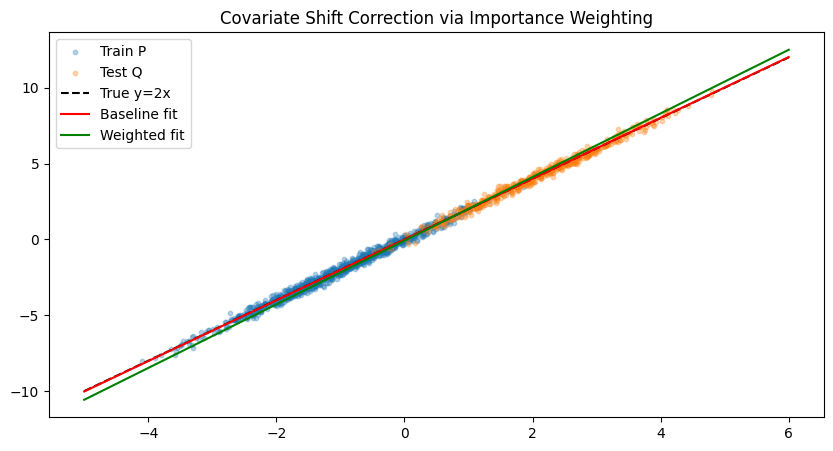

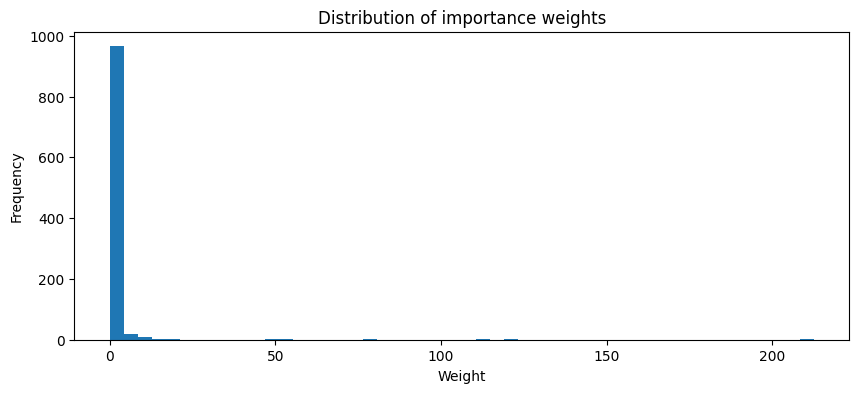

In [5]:
import torch
import torch.optim as optim
import torch.nn as nn
import matplotlib.pyplot as plt

# 设置设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)

# -------------------- 1. 生成协变量偏移数据 --------------------
def make_covariate_shift_data(n_train=1000, n_test=500, noise_std=0.2):
    x_train = torch.randn(n_train, 1) - 1.0
    y_train = 2.0 * x_train + torch.randn(n_train, 1) * noise_std
    x_test = torch.randn(n_test, 1) + 2.0
    y_test = 2.0 * x_test + torch.randn(n_test, 1) * noise_std
    return x_train, y_train, x_test, y_test

# -------------------- 2. 线性回归闭式解（支持加权）--------------------
def fit_linear_regression_closed_form(X, y, w=None):
    X = X.reshape(-1, 1)
    y = y.reshape(-1, 1)
    N = X.shape[0]
    ones = torch.ones(N, 1, device=X.device)
    Phi = torch.cat([X, ones], dim=1)
    if w is None:
        theta = torch.linalg.lstsq(Phi, y).solution
    else:
        w = w.reshape(-1, 1)
        sqrt_w = torch.sqrt(w + 1e-12)
        Phi_w = Phi * sqrt_w
        y_w = y * sqrt_w
        theta = torch.linalg.lstsq(Phi_w, y_w).solution
    return theta[0, 0].item(), theta[1, 0].item()

def predict_linear(X, a, b):
    return a * X + b

def mse(y_pred, y_true):
    return ((y_pred - y_true) ** 2).mean().item()

# -------------------- 3. 逻辑回归分类器（Adam 优化，充分训练）--------------------
def train_logistic_regression(X, y, lr=0.5, steps=10000, print_every=2000):
    """X: [N,1], y: [N,1] 标签 0/1"""
    # 使用 nn.Module 和 Adam 优化器
    class LogisticModel(nn.Module):
        def __init__(self):
            super().__init__()
            self.linear = nn.Linear(1, 1)
        def forward(self, x):
            return torch.sigmoid(self.linear(x))
    model = LogisticModel().to(X.device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss()
    
    for step in range(1, steps+1):
        optimizer.zero_grad()
        p = model(X)
        loss = criterion(p, y)
        loss.backward()
        optimizer.step()
        if step % print_every == 0:
            with torch.no_grad():
                acc = ((p > 0.5).float() == y).float().mean().item()
            print(f"Step {step:6d}: loss={loss.item():.8f}, acc={acc:.4f}")
    # 返回权重和偏置
    w = model.linear.weight.detach()
    b = model.linear.bias.detach()
    return w, b

# -------------------- 4. 主程序 --------------------
x_tr, y_tr, x_te, y_te = make_covariate_shift_data()
print(f"Train x mean: {x_tr.mean().item():.3f}, Test x mean: {x_te.mean().item():.3f}")

# 基线模型
a_base, b_base = fit_linear_regression_closed_form(x_tr, y_tr)
mse_base = mse(predict_linear(x_te, a_base, b_base), y_te)
print(f"Baseline: a={a_base:.3f}, b={b_base:.3f}, Test MSE={mse_base:.6f}")

# 训练逻辑回归区分训练集和测试集
X_mix = torch.cat([x_tr, x_te], dim=0)
y_mix = torch.cat([torch.zeros(x_tr.shape[0], 1), torch.ones(x_te.shape[0], 1)], dim=0)

print("\nTraining logistic regression to distinguish train vs test...")
w_lr, b_lr = train_logistic_regression(X_mix, y_mix, lr=0.5, steps=10000)

# 评估分类器准确率（测试集）
with torch.no_grad():
    p_test = torch.sigmoid(x_te * w_lr + b_lr)
    test_acc = ((p_test > 0.5).float().mean().item())
print(f"\nClassifier accuracy on test set: {test_acc:.4f} (should be ~1.0)")

# 计算训练样本的重要性权重
p_test_train = torch.sigmoid(x_tr * w_lr + b_lr)   # P(test|x)
p_train_train = 1 - p_test_train
weights = (p_test_train / (p_train_train + 1e-12)).detach().squeeze()
weights = weights / weights.mean()   # 归一化

# 加权线性回归
a_w, b_w = fit_linear_regression_closed_form(x_tr, y_tr, w=weights)
mse_weighted = mse(predict_linear(x_te, a_w, b_w), y_te)
print(f"Reweighted: a={a_w:.3f}, b={b_w:.3f}, Test MSE={mse_weighted:.6f}")
print(f"MSE improvement: {mse_base - mse_weighted:.6f}")

# 可视化
x_grid = torch.linspace(-5, 6, 200).view(-1, 1)
y_true = 2.0 * x_grid
y_base = predict_linear(x_grid, a_base, b_base)
y_weighted = predict_linear(x_grid, a_w, b_w)

plt.figure(figsize=(10,5))
plt.scatter(x_tr.numpy(), y_tr.numpy(), s=10, alpha=0.3, label='Train P')
plt.scatter(x_te.numpy(), y_te.numpy(), s=10, alpha=0.3, label='Test Q')
plt.plot(x_grid.numpy(), y_true.numpy(), 'k--', label='True y=2x')
plt.plot(x_grid.numpy(), y_base.numpy(), 'r-', label='Baseline fit')
plt.plot(x_grid.numpy(), y_weighted.numpy(), 'g-', label='Weighted fit')
plt.legend()
plt.title('Covariate Shift Correction via Importance Weighting')
plt.show()

plt.figure(figsize=(10,4))
plt.hist(weights.numpy(), bins=50)
plt.title('Distribution of importance weights')
plt.xlabel('Weight')
plt.ylabel('Frequency')
plt.show()